In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline
print("✅ Librerías cargadas")

✅ Librerías cargadas


In [19]:
df = pd.read_csv('C:\\Users\\HP\\Documents\\EDWIN\\AUTOCAD\\PHYTON\\Proyecto 1\\AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').set_index('Datetime')

# Reducir a datos diarios para que sea más rápido
df_daily = df.resample('D').mean()
print(f"✅ Dataset cargado: {df_daily.shape}")
df_daily.head()

✅ Dataset cargado: (5055, 1)


,AEP_MW
Datetime,
2004-10-01,14284.521739
2004-10-02,12999.875000
2004-10-03,12227.083333
2004-10-04,14309.041667
2004-10-05,14439.708333


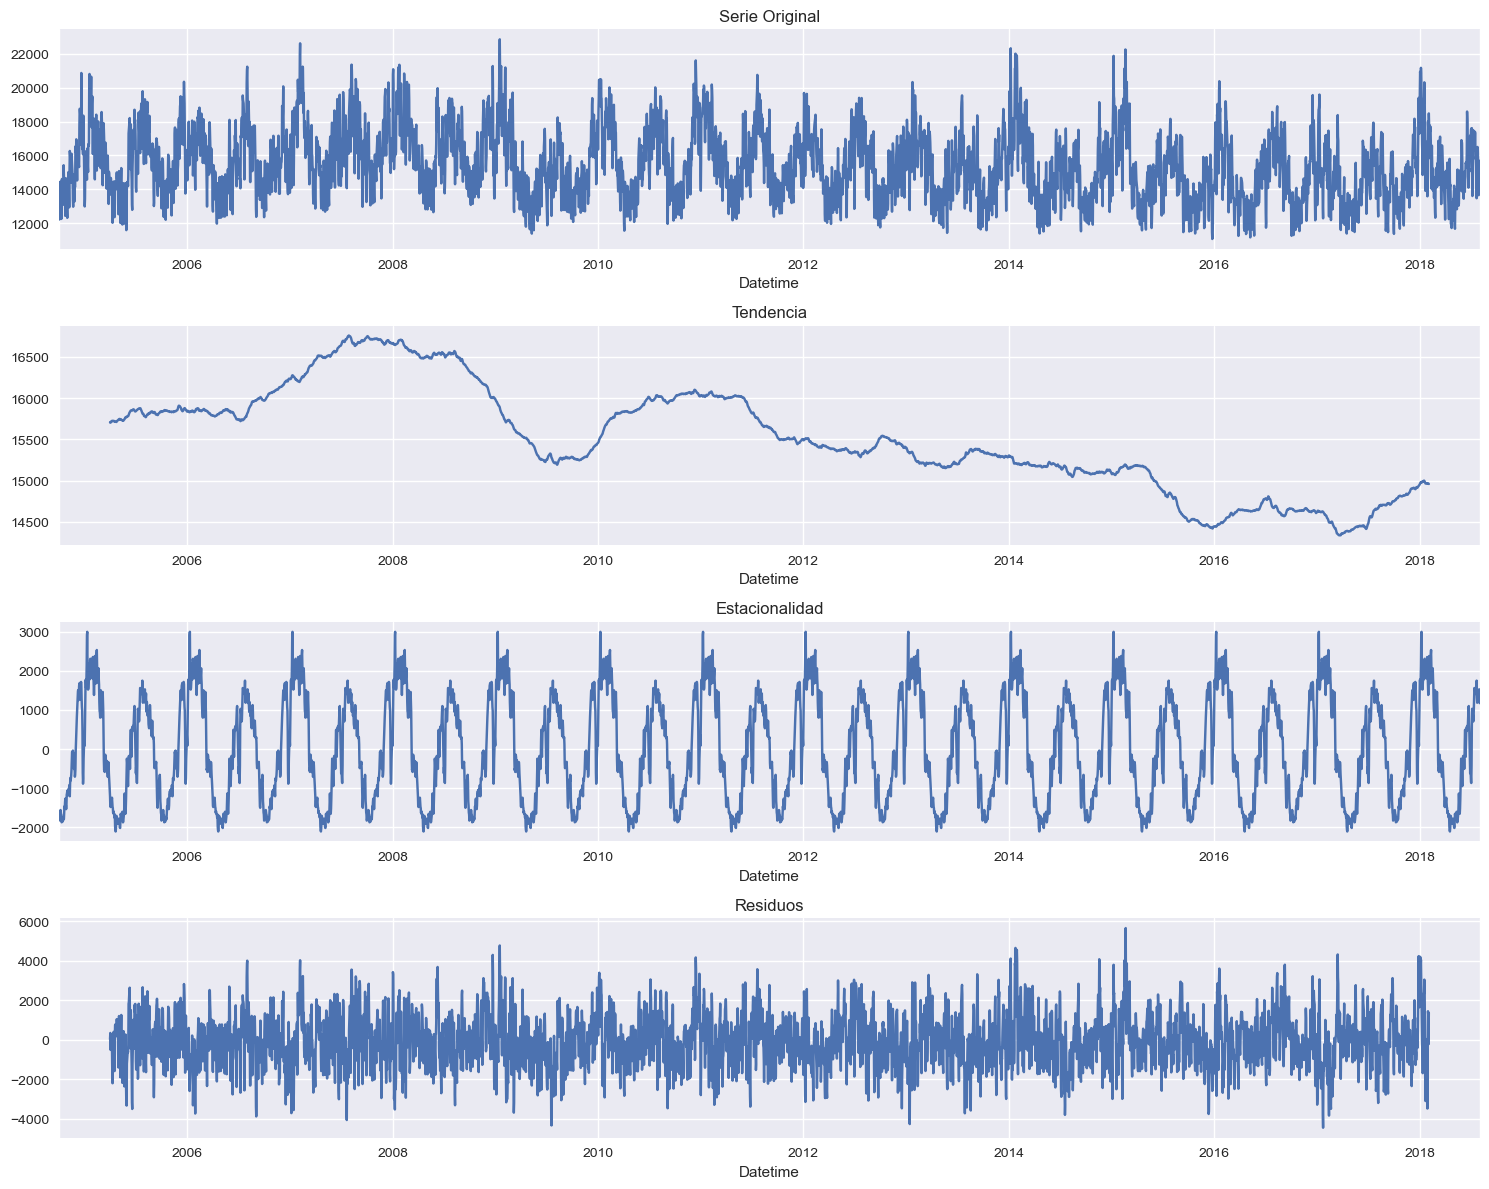

In [21]:
decomposition = seasonal_decompose(df_daily['AEP_MW'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomposition.observed.plot(ax=axes[0], title='Serie Original')
decomposition.trend.plot(ax=axes[1], title='Tendencia')
decomposition.seasonal.plot(ax=axes[2], title='Estacionalidad')
decomposition.resid.plot(ax=axes[3], title='Residuos')
plt.tight_layout()
plt.show()

In [23]:
train = df_daily[df_daily.index < '2017-12-01']
test = df_daily[df_daily.index >= '2017-12-01']

print(f"✅ Train: {len(train)} días")
print(f"✅ Test:  {len(test)} días")

✅ Train: 4809 días
✅ Test:  246 días


In [25]:
model = SARIMAX(train['AEP_MW'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print("✅ Modelo entrenado correctamente")

✅ Modelo entrenado correctamente


In [26]:
pred = results.forecast(steps=len(test))
pred.index = test.index

mae = mean_absolute_error(test['AEP_MW'], pred)
rmse = np.sqrt(mean_squared_error(test['AEP_MW'], pred))
mape = np.mean(np.abs((test['AEP_MW'] - pred) / test['AEP_MW'])) * 100

print(f"📊 Métricas del modelo SARIMA:")
print(f"   MAE:  {mae:.2f} MW")
print(f"   RMSE: {rmse:.2f} MW")
print(f"   MAPE: {mape:.2f}%")

📊 Métricas del modelo SARIMA:
   MAE:  1626.28 MW
   RMSE: 2174.75 MW
   MAPE: 9.87%


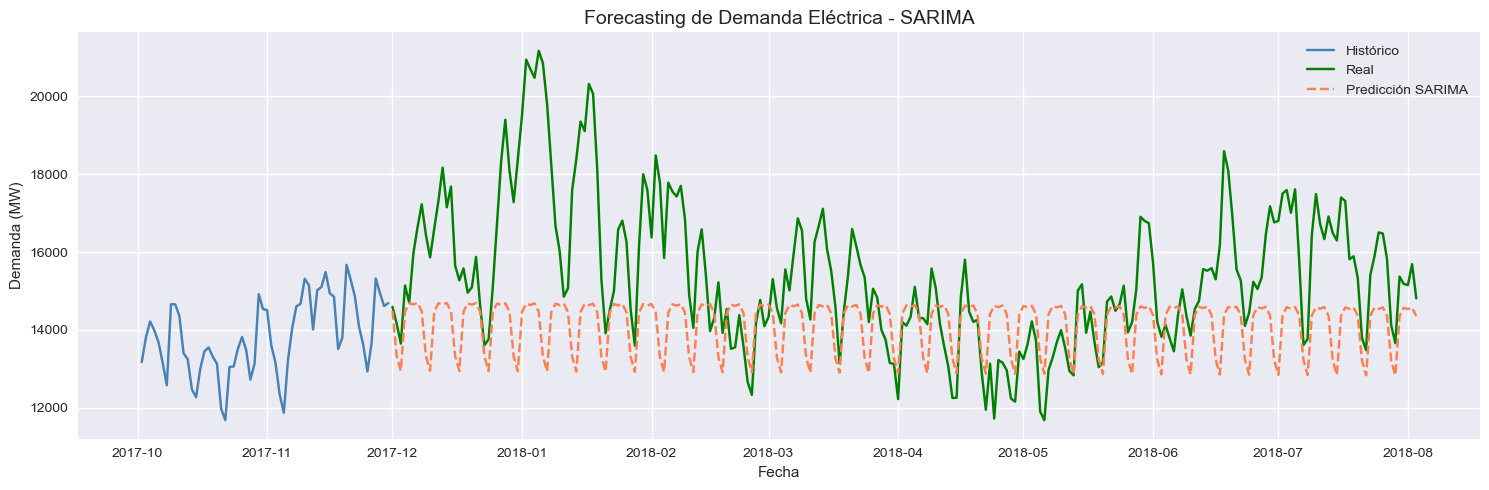

In [29]:
plt.figure(figsize=(15, 5))
plt.plot(train[-60:].index, train[-60:]['AEP_MW'], 
         label='Histórico', color='steelblue')
plt.plot(test.index, test['AEP_MW'], 
         label='Real', color='green')
plt.plot(pred.index, pred, 
         label='Predicción SARIMA', color='coral', linestyle='--')
plt.title('Forecasting de Demanda Eléctrica - SARIMA', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Demanda (MW)')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
import joblib
joblib.dump(results, 'sarima_energy_model.pkl')
print("✅ Modelo guardado como sarima_energy_model.pkl")

✅ Modelo guardado como sarima_energy_model.pkl
